## Chunking
For chunking we use docling and hybrid-chunking.

A chunk contains:
- chunk_id
- doc_id
- doc_name
- text (raw text)
- contextualized_text
- token_count
- meta (docling meta data)


In [1]:
from backend.doc_processing import Doc_Processing
from backend.config import Chunking_Constants
from matplotlib import pyplot as plt


In [2]:
cts = Chunking_Constants()

dp = Doc_Processing(cts)

dp.make_chunks()

Reading Files:   0%|          | 0/1 [00:00<?, ?file/s]

Processing chunks: 0chunk [00:00, ?chunk/s]

In [3]:
doc_chunks = dp.load_chunks()
loaded_chunks = doc_chunks[0]

Reading files:   0%|          | 0/1 [00:00<?, ?file/s]

Reading chunks: 0chunk [00:00, ?chunk/s]

In [4]:
tokens  = [chunk.token_count for chunk in loaded_chunks]

In [5]:
print("Number of chunks:", len(loaded_chunks))


Number of chunks: 387


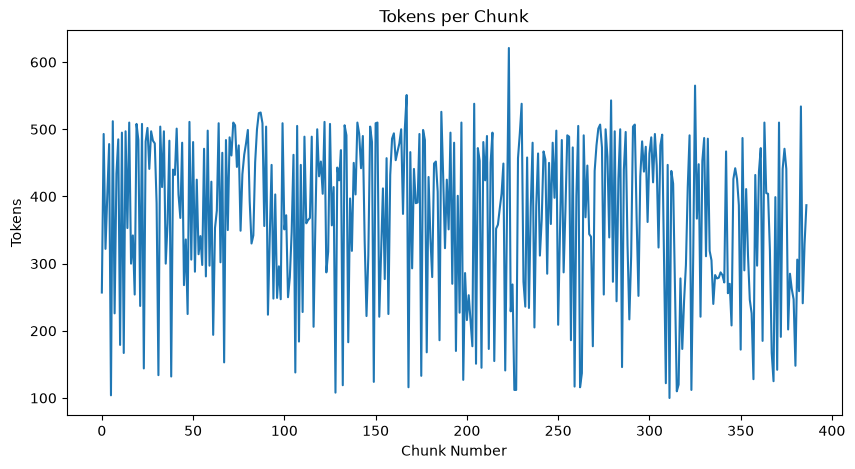

In [6]:
fig, ax = plt.subplots(figsize=(10,5))
ax.set_title(label="Tokens per Chunk")
ax.set_ylabel(ylabel="Tokens")
ax.set_xlabel(xlabel="Chunk Number")
ax.plot(range(len(loaded_chunks)), tokens )
plt.show()

In [7]:
import numpy as np
print(f"mean of tokens: {round(np.mean(tokens), 2)}")
print(f"variance of tokens: {round(np.var(tokens),2)}")

mean of tokens: 367.33
variance of tokens: 14956.35


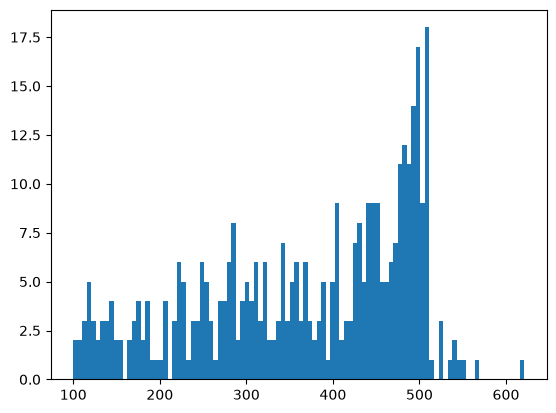

In [8]:
plt.hist(tokens, bins=100)
plt.show()

### Inspecting small Chunks

In [9]:
toks_per_chunks = zip(list(range(len(loaded_chunks))), tokens)
toks_per_chunks = sorted(toks_per_chunks, key= lambda tup: tup[1])

print(toks_per_chunks[:20])

[(311, 100), (5, 104), (128, 108), (315, 110), (226, 112), (227, 112), (323, 112), (168, 116), (262, 116), (259, 117), (132, 119), (316, 120), (309, 122), (149, 124), (368, 125), (198, 127), (357, 128), (38, 132), (175, 133), (31, 134)]


In [10]:
print(doc_chunks[0][0])

chunk_id='0' doc_id='f631a60af3315700112400d55bcecbf264094863cd32660ae0a208dd7130de9c' doc_name='eu_ai_act_2024_1689_DE.pdf' text='zur Festlegung harmonisierter Vorschriften für künstliche Intelligenz und zur Änderung der Verordnungen (EG) Nr. 300/2008, (EU) Nr. 167/2013, (EU) Nr. 168/2013, (EU) 2018/858, (EU) 2018/1139 und (EU) 2019/2144 sowie der Richtlinien 2014/90/EU, (EU) 2016/797 und (EU) 2020/1828 (Verordnung über künstliche Intelligenz)\n(Text von Bedeutung für den EWR)\nDAS EUROPÄISCHE PARLAMENT UND DER RAT DER EUROPÄISCHEN UNION -\ngestützt auf den Vertrag über die Arbeitsweise der Europäischen Union, insbesondere auf die Artikel 16 und 114,\nauf Vorschlag der Europäischen Kommission,\nnach Zuleitung des Entwurfs des Gesetzgebungsakts an die nationalen Parlamente,\nnach Stellungnahme des Europäischen Wirtschafts- und Sozialausschusses ( 1 ),\nnach Stellungnahme der Europäischen Zentralbank ( 2 ),\nnach Stellungnahme des Ausschusses der Regionen ( 3 ),\ngemäß dem ordentlichen 

In [11]:
for chunk_idx, _ in toks_per_chunks[:4]:
    print(f"{loaded_chunks[chunk_idx].contextualized_text!r}")
    print("----------------------------------------------")
    print(f"raw text:: {loaded_chunks[chunk_idx].text!r}")
    print("----------------------------------------------")
    print("----------------------------------------------")

'Verfahren für den Umgang mit KI-Systemen, die vom Anbieter gemäß Anhang III als nicht hochriskant eingestuft werden\n- (8) Bei der Ausübung ihrer Befugnis zur Überwachung der Anwendung dieses Artikels können die Marktüberwachungsbehörden im Einklang mit Artikel 11 der Verordnung (EU) 2019/1020 geeignete Überprüfungen durchführen, wobei sie insbesondere Informationen berücksichtigen, die in der EU-Datenbank gemäß Artikel 71 der vorliegenden Verordnung gespeichert sind.'
----------------------------------------------
raw text:: '- (8) Bei der Ausübung ihrer Befugnis zur Überwachung der Anwendung dieses Artikels können die Marktüberwachungsbehörden im Einklang mit Artikel 11 der Verordnung (EU) 2019/1020 geeignete Überprüfungen durchführen, wobei sie insbesondere Informationen berücksichtigen, die in der EU-Datenbank gemäß Artikel 71 der vorliegenden Verordnung gespeichert sind.'
----------------------------------------------
----------------------------------------------
'vom 13. Juni 2

In [14]:
for chunk_idx, _ in toks_per_chunks[:4]:
    print(loaded_chunks[chunk_idx].meta)
    print(type(loaded_chunks[chunk_idx].meta))
    print("----------------------------------------------")

schema_name='docling_core.transforms.chunker.DocMeta' version='1.0.0' doc_items=[DocItem(self_ref='#/texts/1789', parent=RefItem(cref='#/groups/201'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.LIST_ITEM: 'list_item'>, prov=[ProvenanceItem(page_no=108, bbox=BoundingBox(l=67.40777298048397, t=504.6482445874375, r=529.7774966245839, b=464.7834486253793, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 393))], source=[], comments=[])] headings=['Verfahren für den Umgang mit KI-Systemen, die vom Anbieter gemäß Anhang III als nicht hochriskant eingestuft werden'] captions=None origin=DocumentOrigin(mimetype='application/pdf', binary_hash=16186509757902806684, filename='eu_ai_act_2024_1689_DE.pdf', uri=None)
<class 'docling_core.transforms.chunker.doc_chunk.DocMeta'>
----------------------------------------------
schema_name='docling_core.transforms.chunker.DocMeta' version='1.0.0' doc_items=[DocItem(self_ref='#/texts/35', parent=